# Pretrained DenseNet-121 Classifier — Pneumonia vs Healthy

Train ImageNet-pretrained DenseNet-121 with **backbone frozen** and only final `classifier` head trainable.  
DenseNet-121 is the standard architecture for chest X-ray classification (CheXNet, Rajpurkar 2017).

Uses `pos_weight = sqrt(n_neg / n_pos)` on `BCEWithLogitsLoss` for class imbalance.  
Training set is augmented with light geometric transforms; val/test are not augmented.

**Reported metrics:** Accuracy and AUC-ROC on test set.

## 1. Setup

In [1]:
import sys
import os
import json
from pathlib import Path

project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from classifier import FrozenDenseNet121
from dataset import AugmentedDataset
from device import DEVICE
from metrics import print_metrics, plot_roc_curve
from train_models import run_epoch, train_model, training_curves, save_results
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(f"Device: {DEVICE}")

Device: mps


## 2. Hyperparameters (from YAML)

In [2]:
from config import load_config

cfg = load_config(project_root / "configs" / "densenet121.yaml", project_root)

print(cfg.model.name)
print(cfg.data.img_size)
print(cfg.data.augmentation)
print(cfg.data.class_balancing)
print(cfg.training.batch_size)
print(cfg.training.lr)
print(cfg.training.num_epochs)
print(cfg.training.weight_decay)
print(cfg.training.early_stopping_patience)
print(cfg.seed)

if cfg.data.augmentations:
    print("Using data augmentation with the following parameters:")
    print(cfg.data.augmentations)
else:
    print("No data augmentation will be applied.")

print(cfg.checkpoint_path)
print(cfg.results_dir)

FrozenDenseNet121
[224, 224]
True
pos_weight
32
0.0003
100
0.0001
10
42
Using data augmentation with the following parameters:
namespace(random_rotation_degrees=10, horizontal_flip_p=0.5, random_resized_crop_scale=[0.95, 1.0])
/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/models/densenet121_20260518-094701.pt
/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/densenet121_20260518-094701


In [3]:
IMG_SIZE    = tuple(cfg.data.img_size)
BATCH_SIZE  = cfg.training.batch_size
LR          = cfg.training.lr
NUM_EPOCHS  = cfg.training.num_epochs
SEED        = cfg.seed

CHECKPOINT_PATH = cfg.checkpoint_path
RESULTS_DIR     = cfg.results_dir
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Load Dataset (from cache)

In [4]:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt",   weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt",  weights_only=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 42452 | Val: 8798 | Test: 9425


## 4. Data Augmentation

Applied **only** to the training set. Same light setup used in 1.2:  
`RandomRotation(10°)` · `RandomHorizontalFlip(0.5)` · `RandomResizedCrop(scale=[0.95, 1.0])`.

`ColorJitter` is intentionally **not** used here — ImageNet-pretrained features expect natural-distribution intensities.

In [5]:
aug_transform = transforms.Compose([
    transforms.RandomRotation(degrees=cfg.data.augmentations.random_rotation_degrees),
    transforms.RandomHorizontalFlip(p=cfg.data.augmentations.horizontal_flip_p),
    # transforms.ColorJitter(brightness=cfg.data.augmentations.brightness_jitter),  # disabled
    transforms.RandomResizedCrop(size=IMG_SIZE, scale=tuple(cfg.data.augmentations.random_resized_crop_scale)),
])

aug_train_dataset = AugmentedDataset(train_dataset, aug_transform)
print(f"Augmented training set size: {len(aug_train_dataset)}")

Augmented training set size: 42452


## 5. Model — DenseNet-121 Frozen Backbone

In [6]:
torch.manual_seed(SEED)
model = FrozenDenseNet121().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/mabosco/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 49.7MB/s]


Trainable parameters: 1,025 / 6,954,881


## 6. DataLoaders & pos_weight

In [7]:
train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,       batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_labels = train_dataset.labels[:, 1]  # index 1 = pneumonia
n_pos = train_labels.sum().item()
n_neg = len(train_labels) - n_pos
pos_weight = torch.tensor([np.sqrt(n_neg / n_pos)], dtype=torch.float32).to(DEVICE)

print(f"Train — Healthy: {int(n_neg)} | Pneumonia: {int(n_pos)}")
print(f"Raw ratio: {n_neg/n_pos:.2f}")
print(f"Attenuated pos_weight (sqrt): {pos_weight.item():.2f}")

Train — Healthy: 42229 | Pneumonia: 223
Raw ratio: 189.37
Attenuated pos_weight (sqrt): 13.76


## 7. Loss, Optimizer, Scheduler

In [8]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE)).to(DEVICE)

# Only the trainable parameters (classifier head) are passed to the optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=cfg.training.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

## 8. Training Loop

In [9]:
best_val_auc, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    CHECKPOINT_PATH=CHECKPOINT_PATH,
    device=DEVICE,
    early_stopping_patience=cfg.training.early_stopping_patience,
)

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch 01/100 | elapsed_time=696.02s| train_loss=0.2671 | train_auc=0.5780 | val_loss=0.4514 | val_auc=0.5320 ← best 
Epoch 02/100 | elapsed_time=716.97s| train_loss=0.2562 | train_auc=0.6385 | val_loss=0.5089 | val_auc=0.5232 
Epoch 03/100 | elapsed_time=732.02s| train_loss=0.2532 | train_auc=0.6624 | val_loss=0.3323 | val_auc=0.5406 ← best 
Epoch 04/100 | elapsed_time=478.37s| train_loss=0.2528 | train_auc=0.6656 | val_loss=0.4531 | val_auc=0.5314 
Epoch 05/100 | elapsed_time=396.83s| train_loss=0.2492 | train_auc=0.6832 | val_loss=0.4499 | val_auc=0.5366 
Epoch 06/100 | elapsed_time=392.16s| train_loss=0.2448 | train_auc=0.7052 | val_loss=0.4777 | val_auc=0.5226 
Epoch 07/100 | elapsed_time=385.42s| train_loss=0.2491 | train_auc=0.6950 | val_loss=0.4346 | val_auc=0.5313 
Epoch 08/100 | elapsed_time=397.25s| train_loss=0.2427 | train_auc=0.7197 | val_loss=0.4852 | val_auc=0.5322 
Epoch 09/100 | elapsed_time=386.96s| train_loss=0.2427 | train_auc=0.7113 | val_loss=0.3848 | val_auc=0.53

## 9. Training Curves

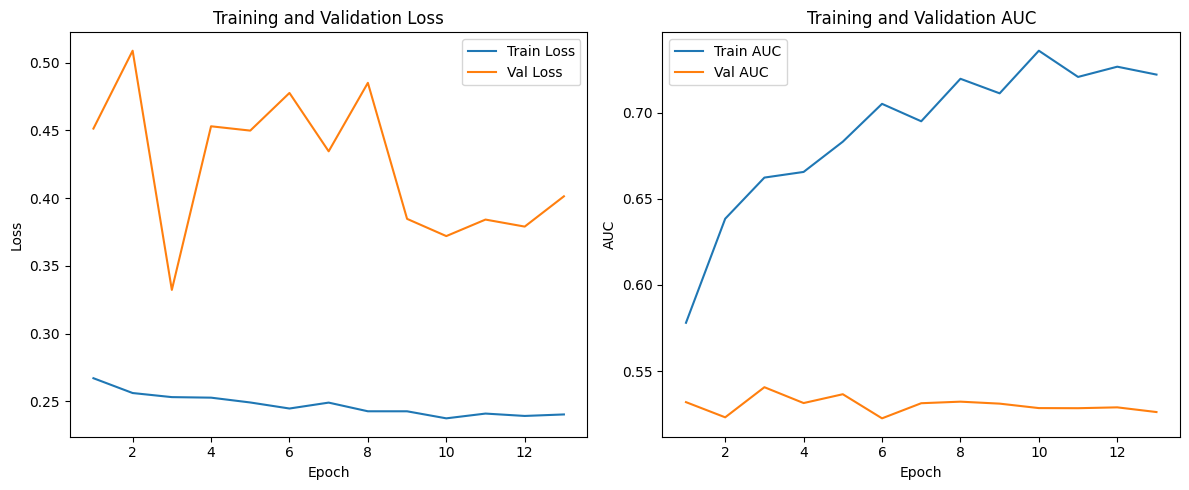

<Figure size 640x480 with 0 Axes>

In [15]:
training_curves(history, results_path=RESULTS_DIR / "training_curves.png")

## 10. Evaluation on Test Set

In [11]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

_, test_y, test_scores = run_epoch(test_loader, model, criterion, device=DEVICE)
_, val_y,  val_sc      = run_epoch(val_loader,  model, criterion, device=DEVICE)

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_threshold = thresholds[np.argmax(tpr - fpr)]

print("=== Test Set Metrics ===")
print_metrics(test_y, test_scores, threshold=best_threshold)

=== Test Set Metrics ===
Accuracy : 0.7949
AUC-ROC  : 0.6207
Confusion matrix (threshold=0.0622384212911129):
  TN=7475  FP=1900
  FN=33  TP=17


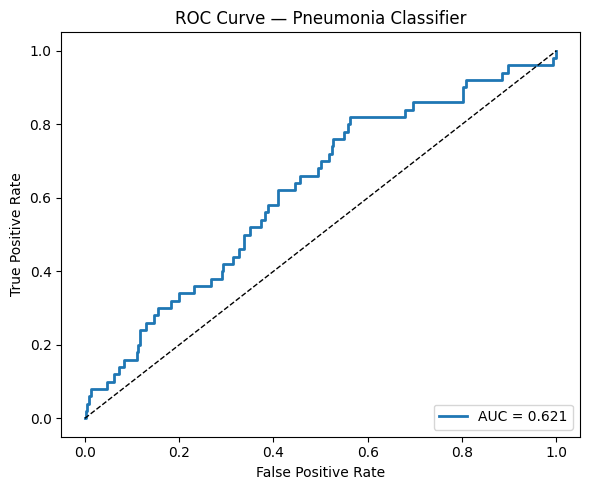

In [12]:
fig = plot_roc_curve(test_y, test_scores, save_path=RESULTS_DIR / "roc_curve_densenet121.png")
plt.show()

## 11. Save Results

In [13]:
def ns_to_dict(ns):
    """Convert SimpleNamespace (or None) to plain dict for JSON."""
    return vars(ns) if ns is not None else None

In [14]:
from metrics import compute_accuracy, compute_roc_auc

save_results(
    model = "ResNet18-Frozen",
    img_size = list(IMG_SIZE),
    epochs = NUM_EPOCHS,
    batch_size = BATCH_SIZE,
    lr = LR,
    seed = SEED,
    pos_weight = pos_weight,
    best_val_auc = best_val_auc,
    augmentation = ns_to_dict(cfg.data.augmentations),
    test_accuracy = compute_accuracy(test_y, test_scores, threshold=best_threshold),
    test_auc_roc =  compute_roc_auc(test_y, test_scores),
    history = history,
    results_path = RESULTS_DIR / "resnet18_results.json"
)

Results saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/densenet121_20260518-094701/resnet18_results.json
{
  "model": "ResNet18-Frozen",
  "img_size": [
    224,
    224
  ],
  "epochs": 100,
  "batch_size": 32,
  "lr": 0.0003,
  "dropout": 0.5,
  "seed": 42,
  "pos_weight": 13.7611,
  "augmentation": {
    "random_rotation_degrees": 10,
    "horizontal_flip_p": 0.5,
    "random_resized_crop_scale": [
      0.95,
      1.0
    ]
  },
  "best_val_auc": 0.5406,
  "test_accuracy": 0.7949,
  "test_auc_roc": 0.6207
}
